In [1]:
%pip install mlflow azureml-mlflow seaborn --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
azure-storage-file-datalake 12.25.0 requires azure-storage-blob>=12.30.0, but you have azure-storage-blob 12.19.0 which is incompatible.
azureml-dataprep 5.5.0 requires cloudpickle<3.0.0,>=1.1.0, but you have cloudpickle 3.1.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

df = pd.read_csv("../data/ai4i_clean.csv")

TARGET = "machine_failure"

NUM_COLS = [
    "air_temp_k",
    "process_temp_k",
    "rpm",
    "torque_nm",
    "tool_wear_min"
]

CAT_COLS = ["type"]

# Use float for all sensor columns
df[NUM_COLS] = df[NUM_COLS].astype(float)

print(df.shape)
df.head()

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [2]:
%pip install --force-reinstall --no-cache-dir numpy==1.26.4 pandas==2.2.2 scikit-learn==1.5.2 --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
azureml-dataprep 5.5.0 requires cloudpickle<3.0.0,>=1.1.0, but you have cloudpickle 3.1.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 1.26.4
Pandas: 2.2.2


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

df = pd.read_csv("../data/ai4i_clean.csv")

TARGET = "machine_failure"

NUM_COLS = [
    "air_temp_k",
    "process_temp_k",
    "rpm",
    "torque_nm",
    "tool_wear_min"
]

CAT_COLS = ["type"]

# Use float for all sensor columns
df[NUM_COLS] = df[NUM_COLS].astype(float)

print(df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/ai4i_clean.csv'

In [3]:
import os

print("Current folder:", os.getcwd())
print("Files/folders here:", os.listdir())

Current folder: /mnt/batch/tasks/shared/LS_root/mounts/clusters/ci-jovaria1096-lab1/code/Users/jiya_21a
Files/folders here: ['.amlignore', '.amlignore.amltmp', '.ipynb_aml_checkpoints', '01_knn_notebook.ipynb', '01_knn_notebook.ipynb.amltmp']


In [4]:
import os

print(os.listdir("../"))

['jiya_21a']


In [5]:
import os

for root, dirs, files in os.walk("/mnt/batch/tasks/shared/LS_root/mounts/clusters/ci-jovaria1096-lab1/code"):
    if "ai4i_clean.csv" in files:
        print("FOUND:", os.path.join(root, "ai4i_clean.csv"))

FOUND: /mnt/batch/tasks/shared/LS_root/mounts/clusters/ci-jovaria1096-lab1/code/azureml-knn-maintenance/data/ai4i_clean.csv
FOUND: /mnt/batch/tasks/shared/LS_root/mounts/clusters/ci-jovaria1096-lab1/code/azureml-knn-maintenance/data/ai4i_table/ai4i_clean.csv


In [6]:
df = pd.read_csv("../data/ai4i_clean.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/ai4i_clean.csv'

In [7]:
df = pd.read_csv("../data/ai4i_clean.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/ai4i_clean.csv'

In [8]:
df = pd.read_csv("../data/ai4i_clean.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/ai4i_clean.csv'

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Load dataset
df = pd.read_csv(
    "/mnt/batch/tasks/shared/LS_root/mounts/clusters/ci-jovaria1096-lab1/code/azureml-knn-maintenance/data/ai4i_clean.csv"
)

TARGET = "machine_failure"

NUM_COLS = [
    "air_temp_k",
    "process_temp_k",
    "rpm",
    "torque_nm",
    "tool_wear_min"
]

CAT_COLS = ["type"]

df[NUM_COLS] = df[NUM_COLS].astype(float)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 7)


,type,air_temp_k,process_temp_k,rpm,torque_nm,tool_wear_min,machine_failure
0,M,298.1,308.6,1551.0,42.8,0.0,0
1,L,298.2,308.7,1408.0,46.3,3.0,0
2,L,298.1,308.5,1498.0,49.4,5.0,0
3,L,298.2,308.6,1433.0,39.5,7.0,0
4,L,298.2,308.7,1408.0,40.0,9.0,0


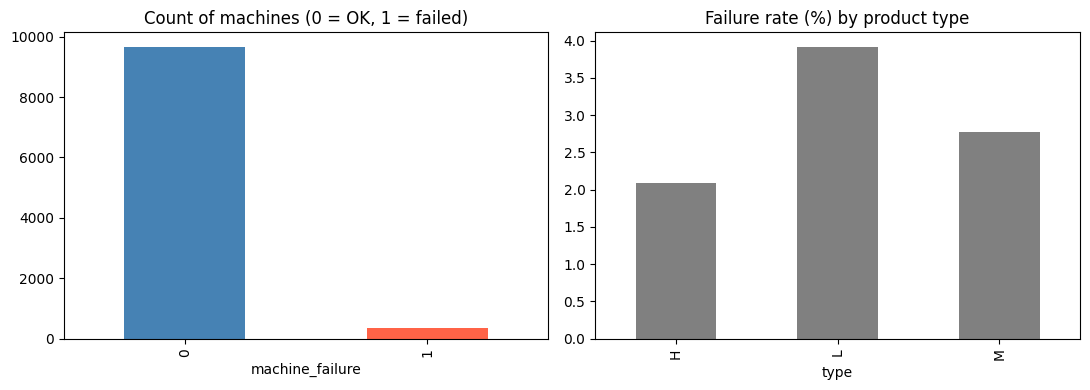

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df[TARGET].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color=["steelblue", "tomato"]
)

axes[0].set_title("Count of machines (0 = OK, 1 = failed)")

df.groupby("type")[TARGET].mean().mul(100).plot(
    kind="bar",
    ax=axes[1],
    color="gray"
)

axes[1].set_title("Failure rate (%) by product type")

plt.tight_layout()
plt.show()

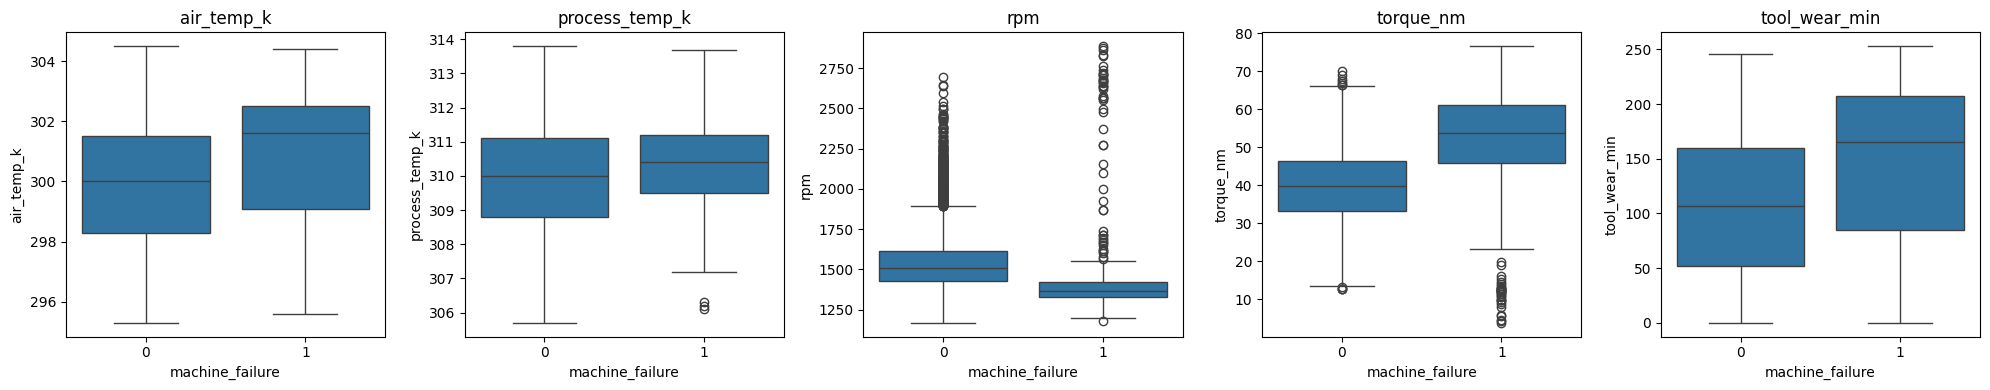

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, col in zip(axes, NUM_COLS):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [12]:
df[NUM_COLS].describe().T[["min", "max", "mean", "std"]].round(1)

,min,max,mean,std
air_temp_k,295.3,304.5,300.0,2.0
process_temp_k,305.7,313.8,310.0,1.5
rpm,1168.0,2886.0,1538.8,179.3
torque_nm,3.8,76.6,40.0,10.0
tool_wear_min,0.0,253.0,108.0,63.7


In [13]:
X = df[NUM_COLS + CAT_COLS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape, "failure rate", round(y_train.mean(), 4))
print("Test: ", X_test.shape, "failure rate", round(y_test.mean(), 4))

Train: (8000, 6) failure rate 0.0339
Test:  (2000, 6) failure rate 0.034


In [14]:
def make_pipeline(scale=True, k=5):
    num_step = StandardScaler() if scale else "passthrough"

    prep = ColumnTransformer([
        ("num", num_step, NUM_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
    ])

    return Pipeline([
        ("prep", prep),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])


for scale in [False, True]:
    model = make_pipeline(scale=scale).fit(X_train, y_train)

    pred = model.predict(X_test)

    print(
        f"Scaling={str(scale):5} "
        f"accuracy={accuracy_score(y_test, pred):.3f} "
        f"recall={recall_score(y_test, pred):.3f} "
        f"F1={f1_score(y_test, pred):.3f}"
    )

Scaling=False accuracy=0.970 recall=0.206 F1=0.318
Scaling=True  accuracy=0.974 recall=0.294 F1=0.435


In [15]:
param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    make_pipeline(scale=True),
    param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validated F1:", round(grid.best_score_, 3))

Best parameters: {'knn__n_neighbors': 1, 'knn__p': 1, 'knn__weights': 'uniform'}
Best cross-validated F1: 0.509


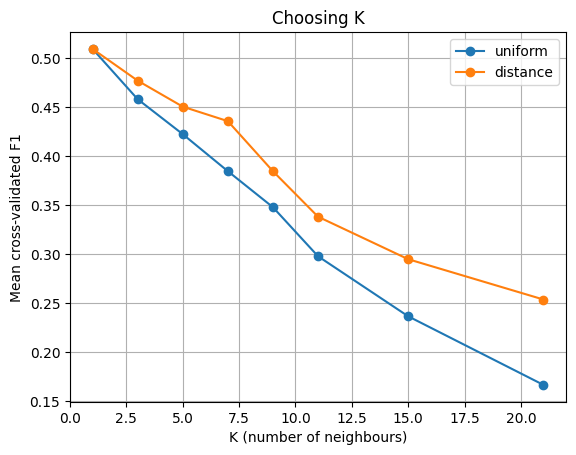

In [16]:
res = pd.DataFrame(grid.cv_results_)

res = res[
    res["param_knn__p"] == grid.best_params_["knn__p"]
]

for w in ["uniform", "distance"]:
    sub = res[res["param_knn__weights"] == w]

    plt.plot(
        sub["param_knn__n_neighbors"].astype(int),
        sub["mean_test_score"],
        marker="o",
        label=w
    )

plt.xlabel("K (number of neighbours)")
plt.ylabel("Mean cross-validated F1")
plt.title("Choosing K")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
v

NameError: name 'v' is not defined

{'accuracy': 0.964, 'precision': 0.453, 'recall': 0.353, 'f1': 0.397, 'auc': 0.669}
              precision    recall  f1-score   support

          OK       0.98      0.98      0.98      1932
     Failure       0.45      0.35      0.40        68

    accuracy                           0.96      2000
   macro avg       0.72      0.67      0.69      2000
weighted avg       0.96      0.96      0.96      2000



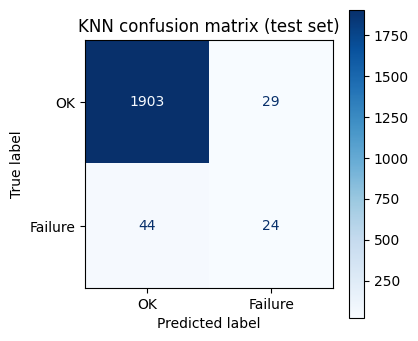

In [18]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "auc": roc_auc_score(y_test, y_prob),
}

print({k: round(v, 3) for k, v in metrics.items()})

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["OK", "Failure"]
    )
)

fig, ax = plt.subplots(figsize=(4, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["OK", "Failure"],
    cmap="Blues",
    ax=ax
)

ax.set_title("KNN confusion matrix (test set)")

fig.savefig(
    "confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [19]:
for t in [0.5, 0.4, 0.3, 0.2]:
    p = (y_prob >= t).astype(int)

    print(
        f"threshold={t}: "
        f"recall={recall_score(y_test, p):.3f} "
        f"precision={precision_score(y_test, p, zero_division=0):.3f}"
    )

threshold=0.5: recall=0.353 precision=0.453
threshold=0.4: recall=0.353 precision=0.453
threshold=0.3: recall=0.353 precision=0.453
threshold=0.2: recall=0.353 precision=0.453


In [20]:
import mlflow
import mlflow.sklearn

from mlflow.models import infer_signature
from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential

SUBSCRIPTION_ID = "54f5826e-8e69-4455-94aa-6a7a486e7171"

RESOURCE_GROUP = "rg-mlab1-jovaria1096"

WORKSPACE = "mlw-lab1-jovaria1096"

ml_client = MLClient(
    DefaultAzureCredential(),
    SUBSCRIPTION_ID,
    RESOURCE_GROUP,
    WORKSPACE
)

mlflow.set_tracking_uri(
    ml_client.workspaces.get(WORKSPACE).mlflow_tracking_uri
)

mlflow.set_experiment("knn-predictive-maintenance")

print("MLflow connected successfully!")

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/10/04 08:16:15 INFO mlflow.tracking.fluent: Experiment with name 'knn-predictive-maintenance' does not exist. Creating a new experiment.


MLflow connected successfully!


In [21]:
MLflow connected successfully!

SyntaxError: invalid syntax (3143979223.py, line 1)

In [22]:
signature = infer_signature(
    X_test,
    best_model.predict(X_test)
)

with mlflow.start_run(
    run_name="knn-notebook-gridsearch"
) as run:

    mlflow.log_params(grid.best_params_)

    mlflow.log_param(
        "scaler",
        "StandardScaler"
    )

    mlflow.log_metric(
        "cv_best_f1",
        grid.best_score_
    )

    mlflow.log_metrics({
        f"test_{k}": v
        for k, v in metrics.items()
    })

    mlflow.log_artifact(
        "confusion_matrix.png"
    )

    mlflow.sklearn.log_model(
        best_model,
        artifact_path="model",
        signature=signature,
        input_example=X_test.head(3),
        registered_model_name="knn-maintenance-notebook",
    )

    print("Run ID:", run.info.run_id)

🏃 View run knn-notebook-gridsearch at: https://eastus.api.azureml.ms/mlflow/v2.0/subscriptions/54f5826e-8e69-4455-94aa-6a7a486e7171/resourceGroups/rg-mlab1-jovaria1096/providers/Microsoft.MachineLearningServices/workspaces/mlw-lab1-jovaria1096/#/experiments/f909ac3a-52e5-4058-969e-57197afa2d75/runs/eb2b08ce-3252-44fa-aff5-5efba5d447c3
🧪 View experiment at: https://eastus.api.azureml.ms/mlflow/v2.0/subscriptions/54f5826e-8e69-4455-94aa-6a7a486e7171/resourceGroups/rg-mlab1-jovaria1096/providers/Microsoft.MachineLearningServices/workspaces/mlw-lab1-jovaria1096/#/experiments/f909ac3a-52e5-4058-969e-57197afa2d75


TypeError: azureml_artifacts_builder() got an unexpected keyword argument 'tracking_uri'

In [23]:
import mlflow
import azureml.mlflow

print("MLflow version:", mlflow.__version__)

MLflow version: 3.16.0


In [24]:
%pip install "mlflow==2.16.2" "azureml-mlflow==1.57.0" --quiet

Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import mlflow
import azureml.mlflow

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("MLflow:", mlflow.__version__)

NumPy: 1.26.4
Pandas: 2.2.2
MLflow: 2.16.2


In [2]:
v

NameError: name 'v' is not defined

In [3]:
df = pd.read_csv("../data/ai4i_clean.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/ai4i_clean.csv'

In [4]:
import pandas as pd

df = pd.read_csv(
    "/mnt/batch/tasks/shared/LS_root/mounts/clusters/ci-jovaria1096-lab1/code/azureml-knn-maintenance/data/ai4i_clean.csv"
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 7)


,type,air_temp_k,process_temp_k,rpm,torque_nm,tool_wear_min,machine_failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [5]:
print("Failure counts:")
print(df["machine_failure"].value_counts())

print("\nFailure rate:")
print(df["machine_failure"].mean())

Failure counts:
machine_failure
0    9661
1     339
Name: count, dtype: int64

Failure rate:
0.0339


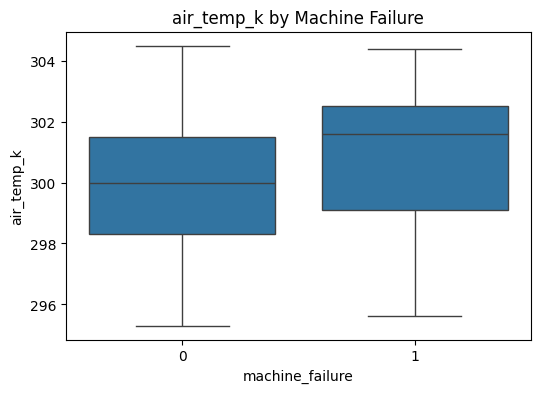

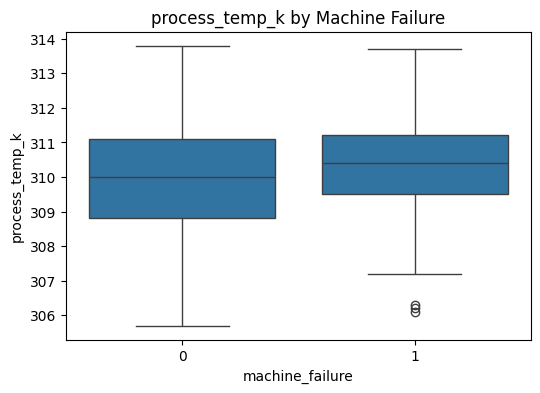

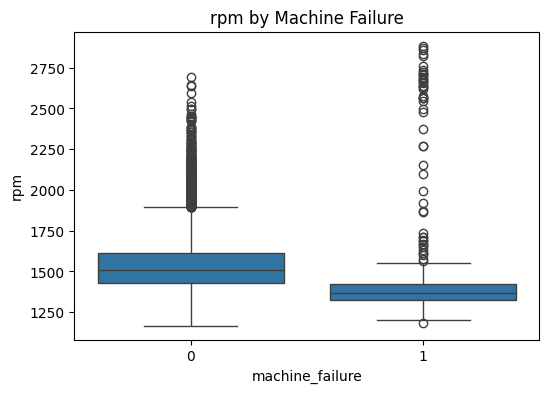

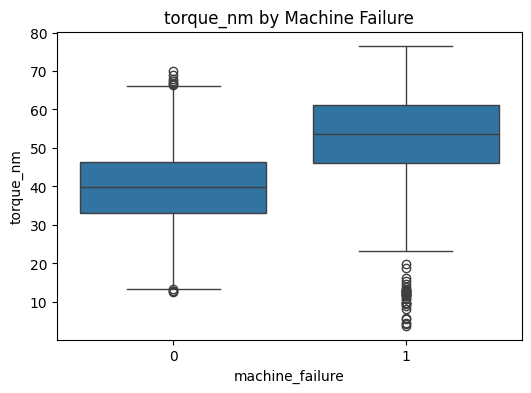

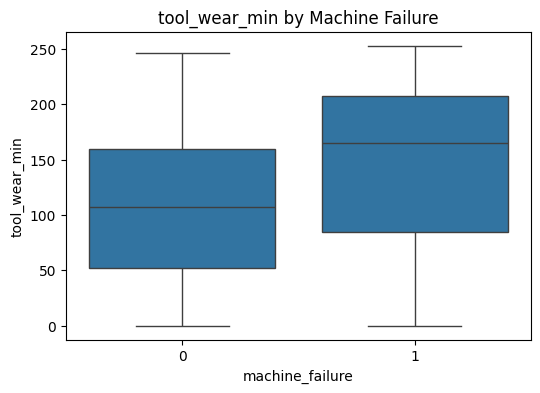

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    "air_temp_k",
    "process_temp_k",
    "rpm",
    "torque_nm",
    "tool_wear_min"
]

for col in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="machine_failure", y=col)
    plt.title(f"{col} by Machine Failure")
    plt.show()

In [7]:
df[[
    "air_temp_k",
    "process_temp_k",
    "rpm",
    "torque_nm",
    "tool_wear_min"
]].describe()

,air_temp_k,process_temp_k,rpm,torque_nm,tool_wear_min
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


In [8]:
signature = infer_signature(
    X_test,
    best_model.predict(X_test)
)

with mlflow.start_run(
    run_name="knn-notebook-gridsearch"
) as run:

    mlflow.log_params(grid.best_params_)

    mlflow.log_param(
        "scaler",
        "StandardScaler"
    )

    mlflow.log_metric(
        "cv_best_f1",
        grid.best_score_
    )

    mlflow.log_metrics({
        f"test_{k}": v
        for k, v in metrics.items()
    })

    mlflow.sklearn.log_model(
        best_model,
        artifact_path="model",
        signature=signature,
        input_example=X_test.head(3),
        registered_model_name="knn-maintenance-notebook",
    )

    print("Run ID:", run.info.run_id)

NameError: name 'infer_signature' is not defined

In [9]:
from mlflow.models import infer_signature

In [10]:
signature = infer_signature(
    X_test,
    best_model.predict(X_test)
)

with mlflow.start_run(
    run_name="knn-notebook-gridsearch"
) as run:

    mlflow.log_params(grid.best_params_)

    mlflow.log_param(
        "scaler",
        "StandardScaler"
    )

    mlflow.log_metric(
        "cv_best_f1",
        grid.best_score_
    )

    mlflow.log_metrics({
        f"test_{k}": v
        for k, v in metrics.items()
    })

    mlflow.sklearn.log_model(
        best_model,
        artifact_path="model",
        signature=signature,
        input_example=X_test.head(3),
        registered_model_name="knn-maintenance-notebook",
    )

    print("Run ID:", run.info.run_id)

NameError: name 'X_test' is not defined

In [11]:
from mlflow.models import infer_signature
import mlflow
import mlflow.sklearn

signature = infer_signature(
    X_test,
    best_model.predict(X_test)
)

with mlflow.start_run(
    run_name="knn-notebook-gridsearch"
) as run:

    mlflow.log_params(grid.best_params_)

    mlflow.log_param(
        "scaler",
        "StandardScaler"
    )

    mlflow.log_metric(
        "cv_best_f1",
        grid.best_score_
    )

    mlflow.log_metrics({
        f"test_{k}": v
        for k, v in metrics.items()
    })

    mlflow.sklearn.log_model(
        best_model,
        artifact_path="model",
        signature=signature,
        input_example=X_test.head(3),
        registered_model_name="knn-maintenance-notebook",
    )

    print("Run ID:", run.info.run_id)

NameError: name 'X_test' is not defined

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop("machine_failure", axis=1)
y = df["machine_failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (8000, 6)
Test: (2000, 6)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

ValueError: could not convert string to float: 'M'

In [14]:
df = pd.read_csv(
    "/mnt/batch/tasks/shared/LS_root/mounts/clusters/ci-jovaria1096-lab1/code/azureml-knn-maintenance/data/ai4i_clean.csv"
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 7)


,type,air_temp_k,process_temp_k,rpm,torque_nm,tool_wear_min,machine_failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

ValueError: could not convert string to float: 'M'

In [16]:
X = df.drop("machine_failure", axis=1)

# Convert machine type into numeric columns
X = pd.get_dummies(X, columns=["type"], drop_first=True)

y = df["machine_failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print(X_train.dtypes)

Train: (8000, 7)
Test: (2000, 7)
air_temp_k        float64
process_temp_k    float64
rpm                 int64
torque_nm         float64
tool_wear_min       int64
type_L               bool
type_M               bool
dtype: object


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")


Scaling completed.


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("Best cross-validated F1:", round(grid.best_score_, 3))

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

y_pred = best_model.predict(X_test)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "auc": roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])
}

print(metrics)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

{'accuracy': 0.9635, 'precision': 0.4528301886792453, 'recall': 0.35294117647058826, 'f1': 0.39669421487603307, 'auc': 0.6689654122518573}

Confusion Matrix:
[[1903   29]
 [  44   24]]


In [20]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

print("MLflow version:", mlflow.__version__)
print("MLflow tracking URI:", mlflow.get_tracking_uri())

MLflow version: 2.16.2
MLflow tracking URI: azureml://eastus.api.azureml.ms/mlflow/v1.0/subscriptions/54f5826e-8e69-4455-94aa-6a7a486e7171/resourceGroups/rg-mlab1-jovaria1096/providers/Microsoft.MachineLearningServices/workspaces/mlw-lab1-jovaria1096


In [21]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

signature = infer_signature(
    X_test,
    best_model.predict(X_test)
)

with mlflow.start_run(
    run_name="knn-notebook-gridsearch"
) as run:

    mlflow.log_params(grid.best_params_)

    mlflow.log_param(
        "scaler",
        "StandardScaler"
    )

    mlflow.log_metric(
        "cv_best_f1",
        grid.best_score_
    )

    mlflow.log_metrics({
        f"test_{k}": v
        for k, v in metrics.items()
    })

    mlflow.sklearn.log_model(
        best_model,
        artifact_path="model",
        signature=signature,
        input_example=X_test.head(3),
        registered_model_name="knn-maintenance-notebook"
    )

    print("Run ID:", run.info.run_id)

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/mlflow/types/utils.py:407: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/azureml/mlflow/_protos/aml_service_pb2.py:10: UserWarning: google.protobuf.service module is deprecated. RPC implementations should provide code generator plugi

Run ID: 0e14137b-3748-4f12-9f35-a823bf0db425


In [22]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

signature = infer_signature(
    X_test,
    best_model.predict(X_test)
)

with mlflow.start_run(
    run_name="knn-notebook-gridsearch"
) as run:

    mlflow.log_params(grid.best_params_)

    mlflow.log_param(
        "scaler",
        "StandardScaler"
    )

    mlflow.log_metric(
        "cv_best_f1",
        grid.best_score_
    )

    mlflow.log_metrics({
        f"test_{k}": v
        for k, v in metrics.items()
    })

    mlflow.sklearn.log_model(
        best_model,
        artifact_path="model",
        signature=signature,
        input_example=X_test.head(3),
        registered_model_name="knn-maintenance-notebook"
    )

    print("Run ID:", run.info.run_id)

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/mlflow/types/utils.py:407: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'knn-maintenance-notebook' already exists. Creating a new version of this model...
2026/10/04 08:37:43 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish c

Run ID: f4f3053d-395b-4cf6-805b-b04c26139f52
